                  round_robin_CV  real_identity_CV   ratio
blocks_mined              0.0000            5.6296     inf
avg_transactions          0.0058            0.8459   145.8
avg_volume                0.0340            1.4369    42.3
avg_fee                   0.0363            1.2006    33.1
fee_volatility            0.4335            1.7921     4.1
avg_block_size            0.0046            0.8644   187.9
difficulty                0.0003            2.1460  7153.3
profitability             0.0363            1.1938    32.9
age                       0.9412            1.7559     1.9


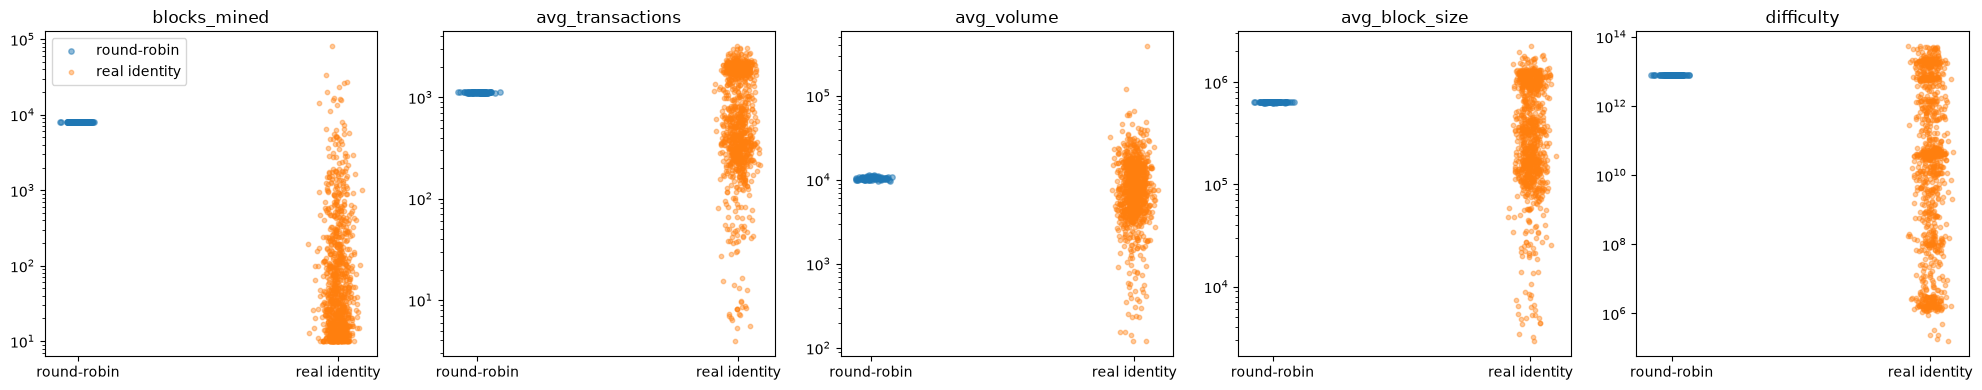

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rr_df = pd.read_csv("../data/round_robin_miner_df.csv")
real_df = pd.read_csv("../data/real_identity_miner_df.csv")

# use proxy fee as a comparison
real_df = real_df.rename(columns={
    'avg_fee_proxy': 'avg_fee',
    'fee_volatility_proxy': 'fee_volatility',
    'profitability_proxy': 'profitability',
})


# convert satoshis to BTC to match the round robin version
for col in ['avg_volume', 'avg_fee', 'fee_volatility', 'profitability']:
    real_df[col] = real_df[col] / 1e8   # satoshis -> BTC, match preprocess()'s units

feature_columns = ['blocks_mined', 'avg_transactions', 'avg_volume',
                    'avg_fee', 'fee_volatility', 'avg_block_size',
                    'difficulty', 'profitability', 'age']

cv_compare = pd.DataFrame({
    'round_robin_CV':   rr_df[feature_columns].std() / rr_df[feature_columns].mean(),
    'real_identity_CV': real_df[feature_columns].std() / real_df[feature_columns].mean(),
}).round(4)
cv_compare['ratio'] = (cv_compare['real_identity_CV'] / cv_compare['round_robin_CV']).round(1)
print(cv_compare)

features_to_plot = ['blocks_mined', 'avg_transactions', 'avg_volume', 'avg_block_size', 'difficulty']

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(4*len(features_to_plot), 4))
rng = np.random.default_rng(0)  # jitter only shifts x-position for visibility, not the actual values

for ax, feat in zip(axes, features_to_plot):
    ax.scatter(rng.normal(0, 0.03, len(rr_df)), rr_df[feat], alpha=0.5, s=15, label='round-robin')
    ax.scatter(1 + rng.normal(0, 0.03, len(real_df)), real_df[feat], alpha=0.4, s=10, label='real identity')
    ax.set_yscale('log')
    ax.set_xticks([0, 1], ['round-robin', 'real identity'])
    ax.set_title(feat)
axes[0].legend()
plt.tight_layout()
plt.savefig('feature_spread_scatter.png', dpi=150)
plt.show()

                     round_robin_CV  real_identity_CV  ratio
avg_fee_real                 0.0223            1.5468   69.4
fee_volatility_real          0.4360            2.5849    5.9
profitability_real           0.0223            1.5487   69.4


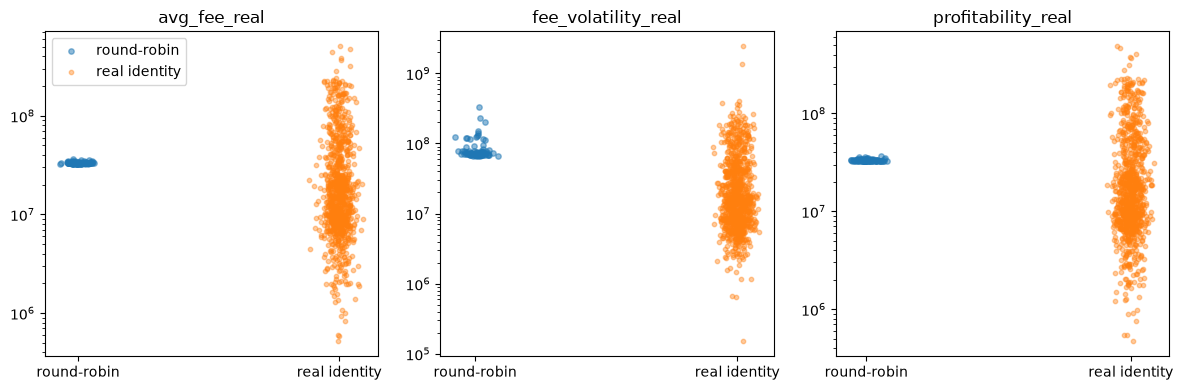

In [19]:
rr_df_fee = pd.read_csv("../data/round_robin_miner_df_with_real_fee.csv")

real_fee_features = ['avg_fee_real', 'fee_volatility_real', 'profitability_real']

cv_real_fee = pd.DataFrame({
    'round_robin_CV':   rr_df_fee[real_fee_features].std() / rr_df_fee[real_fee_features].mean(),
    'real_identity_CV': real_df[real_fee_features].std() / real_df[real_fee_features].mean(),
}).round(4)
cv_real_fee['ratio'] = (cv_real_fee['real_identity_CV'] / cv_real_fee['round_robin_CV']).round(1)
print(cv_real_fee)

features_to_plot_fee = ['avg_fee_real', 'fee_volatility_real', 'profitability_real']

fig, axes = plt.subplots(1, len(features_to_plot_fee), figsize=(4*len(features_to_plot_fee), 4))
rng = np.random.default_rng(0)

for ax, feat in zip(axes, features_to_plot_fee):
    ax.scatter(rng.normal(0, 0.03, len(rr_df_fee)), rr_df_fee[feat], alpha=0.5, s=15, label='round-robin')
    ax.scatter(1 + rng.normal(0, 0.03, len(real_df)), real_df[feat], alpha=0.4, s=10, label='real identity')
    ax.set_yscale('log')
    ax.set_xticks([0, 1], ['round-robin', 'real identity'])
    ax.set_title(feat)
axes[0].legend()
plt.tight_layout()
plt.savefig('feature_spread_scatter_fee.png', dpi=150)
plt.show()

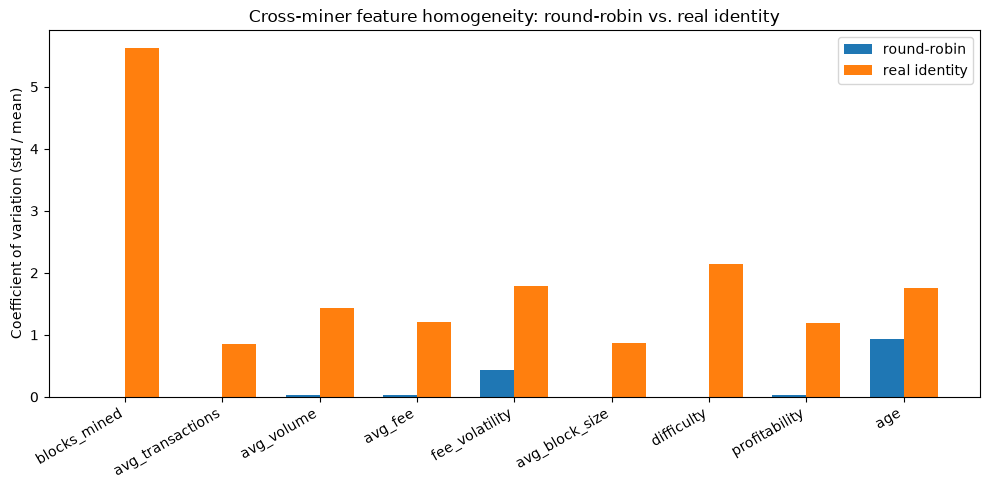

In [3]:
import matplotlib.pyplot as plt
import numpy as np

features = cv_compare.index.tolist()
x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, cv_compare['round_robin_CV'], width, label='round-robin')
ax.bar(x + width/2, cv_compare['real_identity_CV'], width, label='real identity')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha='right')
ax.set_ylabel('Coefficient of variation (std / mean)')
ax.set_title('Cross-miner feature homogeneity: round-robin vs. real identity')
ax.legend()
plt.tight_layout()
plt.savefig('cv_comparison_bar.png', dpi=150)
plt.show()